# Análisis Exploratorio de Datos (EDA)

## Carga de los datos a usar

In [37]:
from importlib.metadata import packages_distributions

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Ruta de la PC de Josué
df = pd.read_csv(r'C:\Users\XPC\Documents\CUC\Cuatri 5\BD - 143 - Programación ll\Trabajos\Proyecto 3\data\raw\Turismo_Historico.csv')

# Ruta de Mauricio
#df = pd.read_csv(r'')


## Uso del Comando HEAD para hacer una revisión superficial de los datos

In [35]:
df.head()

,id,Zona_Pais,Año2017,Año2018,Año2019,Año2020,Año2021,Año2022,Año2023,Año2024,Año2025
0,1,Total,2959869.0,3016667.0,3139008.0,1011912.0,1347055.0,2349537.0,2751134.0,2919483,2943991.0
1,2,América del Norte,1507945.0,1580991.0,1666571.0,571010.0,958792.0,1533502.0,1820038.0,1989725,1999600.0
2,3,Canadá,201921.0,217006.0,234621.0,115632.0,53185.0,183678.0,260744.0,272256,274081.0
3,4,Estados Unidos,1199241.0,1265067.0,1334777.0,434775.0,868986.0,1290038.0,1473620.0,1621340,1627807.0
4,5,México,106783.0,98918.0,97173.0,20603.0,36621.0,59786.0,85674.0,96129,97712.0


## Inspección general

In [36]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   id         100 non-null    int64  
 1   Zona_Pais  100 non-null    str    
 2   Año2017    98 non-null     float64
 3   Año2018    98 non-null     float64
 4   Año2019    98 non-null     float64
 5   Año2020    96 non-null     float64
 6   Año2021    98 non-null     float64
 7   Año2022    98 non-null     float64
 8   Año2023    97 non-null     float64
 9   Año2024    100 non-null    int64  
 10  Año2025    98 non-null     float64
dtypes: float64(8), int64(2), str(1)
memory usage: 8.7 KB


## Resumen estadístico

In [3]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,100.0,50.500000,29.011492,1.0,25.75,50.5,75.25,100.0
Año2017,98.0,152707.265306,449864.719029,13.0,1744.75,12194.5,58359.25,2959869.0
Año2018,98.0,157968.938776,467509.635167,7.0,1874.50,12779.0,60980.50,3016667.0
Año2019,98.0,164604.938776,488791.058532,5.0,1997.25,13189.0,66553.50,3139008.0
Año2020,96.0,54599.677083,162170.546204,14.0,758.75,3966.5,15958.50,1011912.0
Año2021,98.0,77875.397959,253738.367729,1.0,747.50,5287.0,15299.75,1347055.0
Año2022,98.0,132365.938776,414148.412508,1.0,1200.50,8521.5,33128.50,2349537.0
Año2023,97.0,156459.381443,485789.229344,1.0,1783.00,9759.0,43075.00,2751134.0
Año2024,100.0,162248.430000,518060.150581,1.0,1185.50,8760.5,43257.75,2919483.0
Año2025,98.0,167319.969388,526469.504082,73.0,1627.00,9900.0,45389.25,2943991.0


## Valores nulos

In [4]:
df.isna().mean().sort_values(ascending=False)

Año2020      0.04
Año2023      0.03
Año2017      0.02
Año2021      0.02
Año2022      0.02
Año2019      0.02
Año2018      0.02
Año2025      0.02
id           0.00
Zona_Pais    0.00
Año2024      0.00
dtype: float64

#### En nuestro caso, la presencia de valores nulos indica que hay países que no registraron el ingreso de turistas a Costa Rica, por lo que hay que tratar los datos para que esto sea representado como corresponde y los análisis no sean alterados

In [5]:
df_limpio = df.fillna(0)

#### Probamos nuevamente para ver la cantidad de datos nulos que hay en el dataset

In [6]:
df_limpio.isna().mean().sort_values(ascending=False)

id           0.0
Zona_Pais    0.0
Año2017      0.0
Año2018      0.0
Año2019      0.0
Año2020      0.0
Año2021      0.0
Año2022      0.0
Año2023      0.0
Año2024      0.0
Año2025      0.0
dtype: float64

## Histogramas 

### Histograma por Zonas

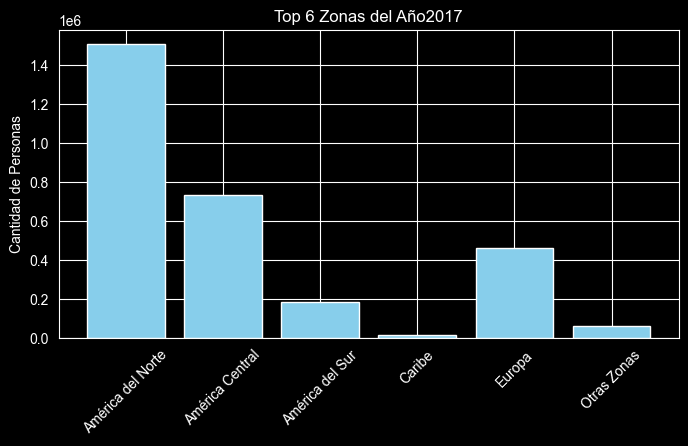

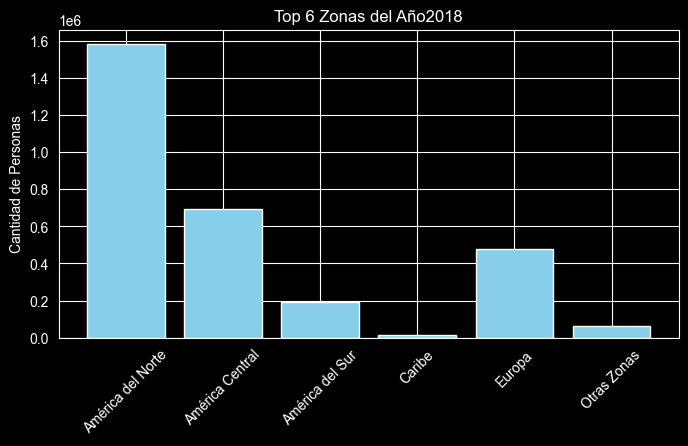

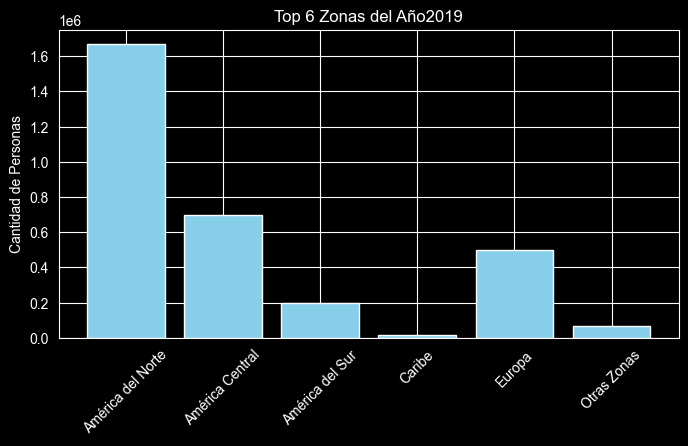

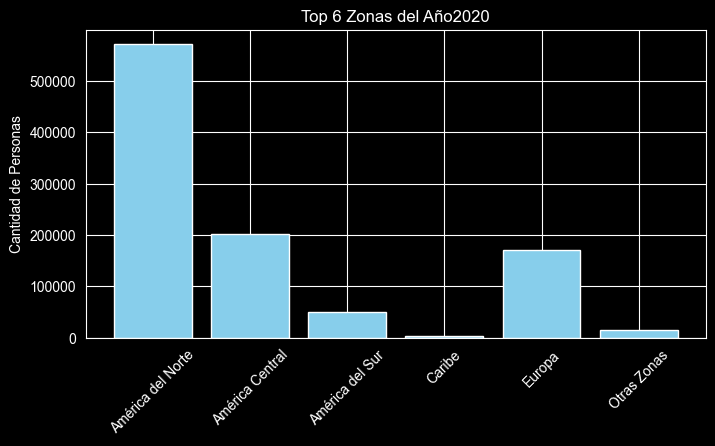

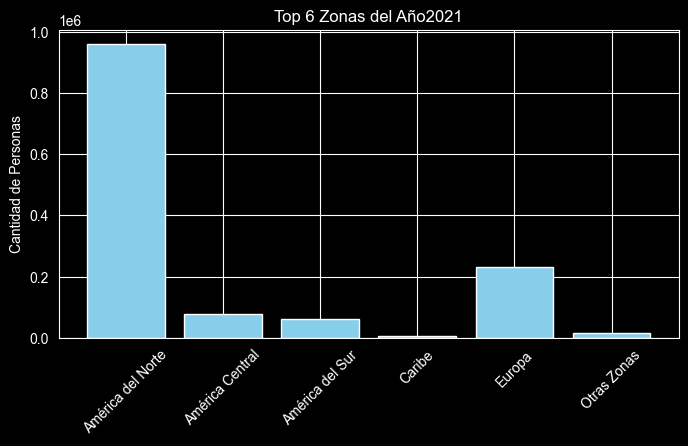

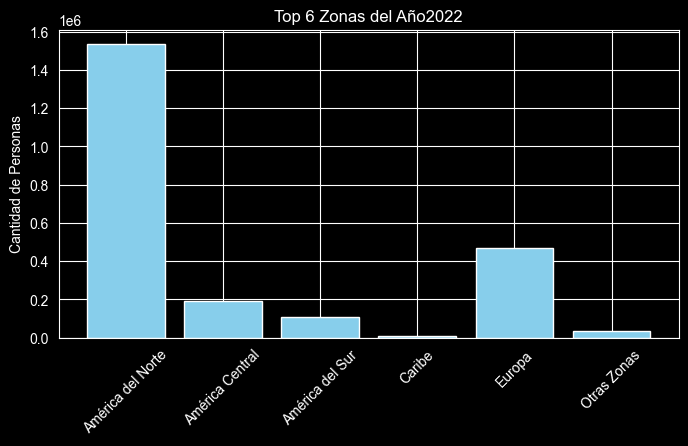

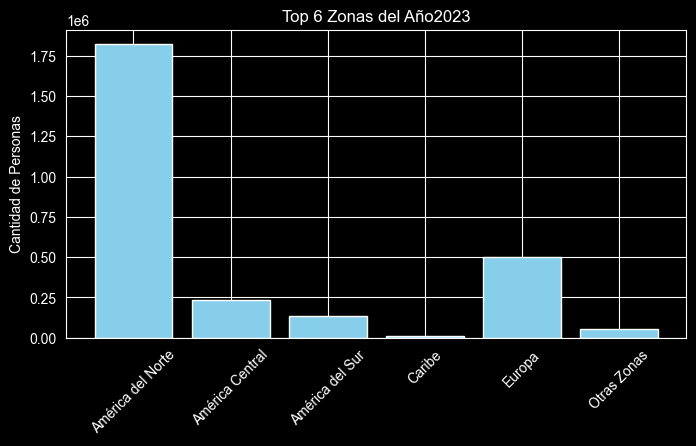

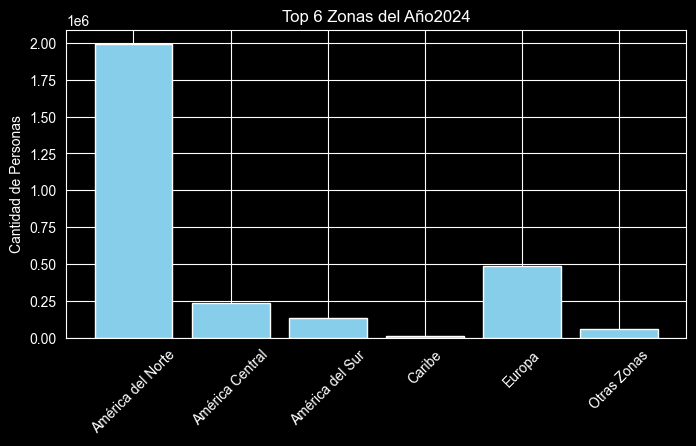

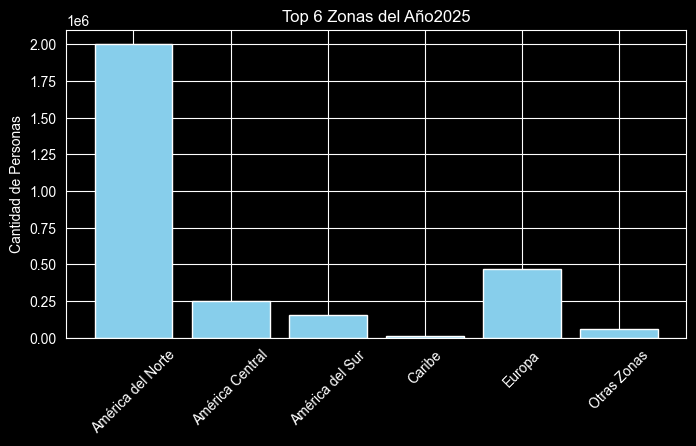

In [40]:
top_6_zonas = df_paises[
    (df_paises['Zona_Pais'] != 'Total') &
    ((df_paises['Zona_Pais'] == 'América del Norte') |
     (df_paises['Zona_Pais'] == 'América Central') |
     (df_paises['Zona_Pais'] == 'América del Sur') |
     (df_paises['Zona_Pais'] == 'Caribe') |
     (df_paises['Zona_Pais'] == 'Europa') |
     (df_paises['Zona_Pais'] == 'Otras Zonas')
     )
].head(6)

for col in num_cols[1:]:
    plt.figure(figsize = (8,4))
    plt.bar(top_6_zonas['Zona_Pais'], top_6_zonas[col], color='skyblue')
    plt.title(f"Top 6 Zonas del {col}")
    plt.ylabel('Cantidad de Personas')
    plt.xticks(rotation=45)
    plt.show()


### Histograma por países

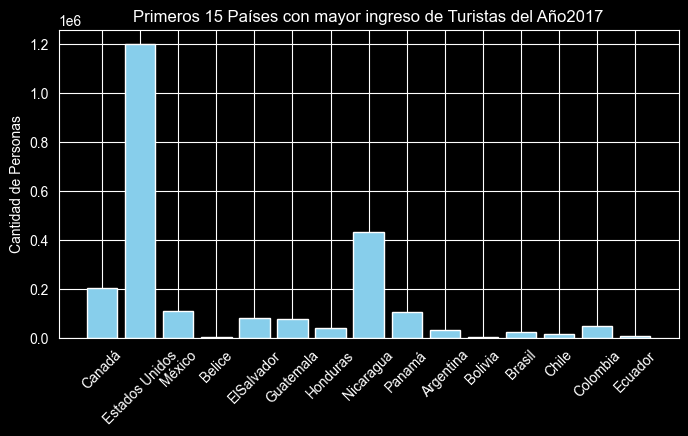

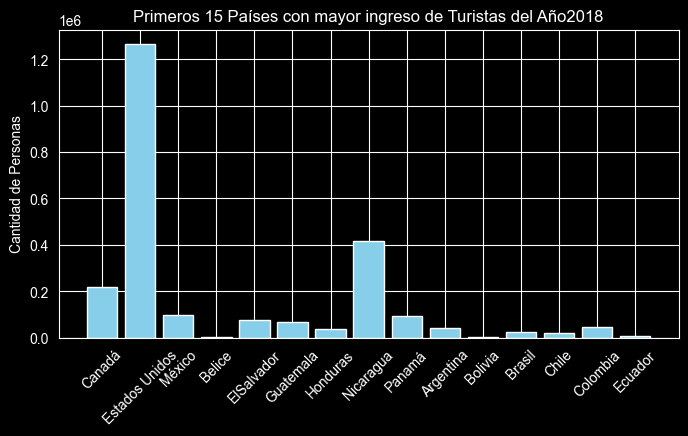

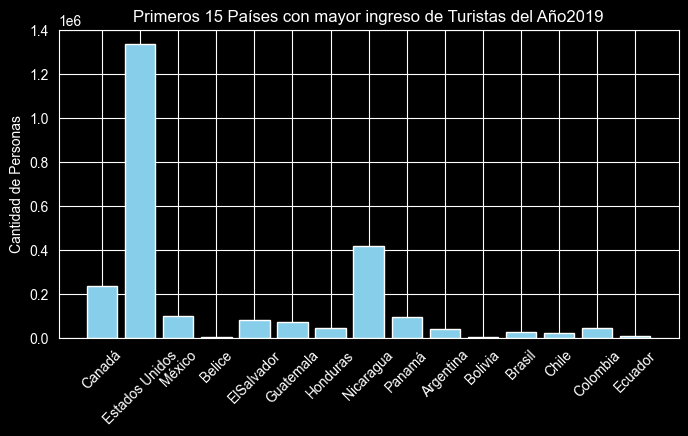

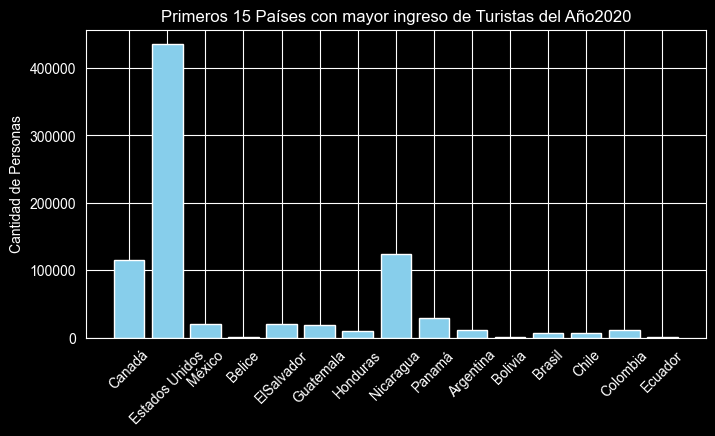

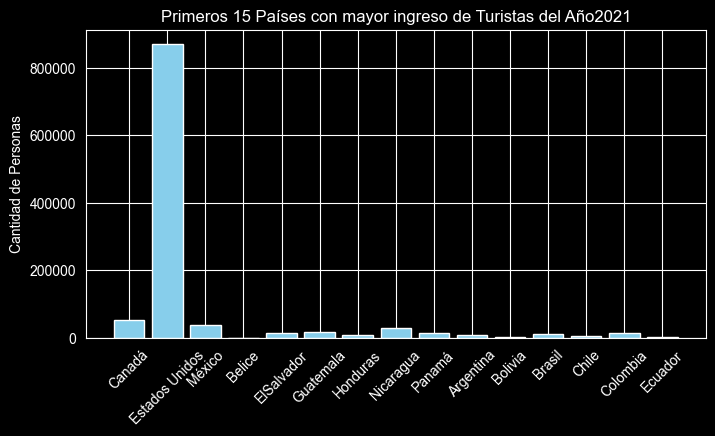

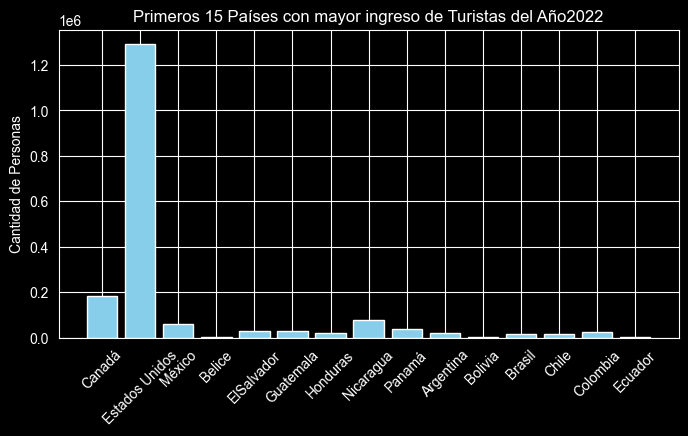

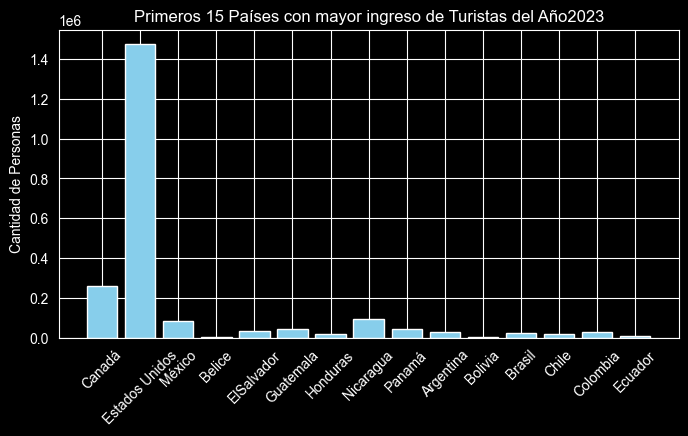

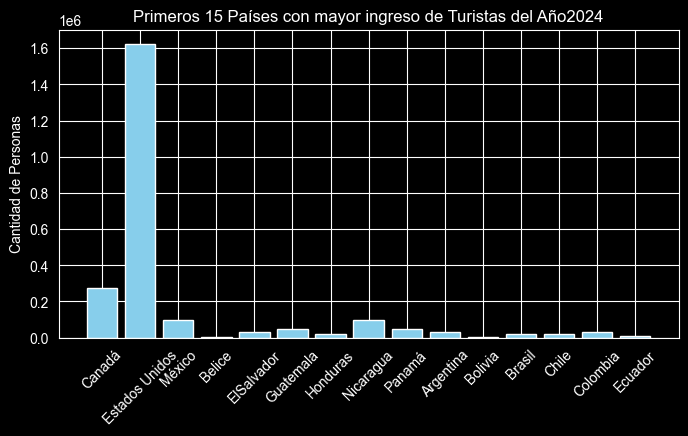

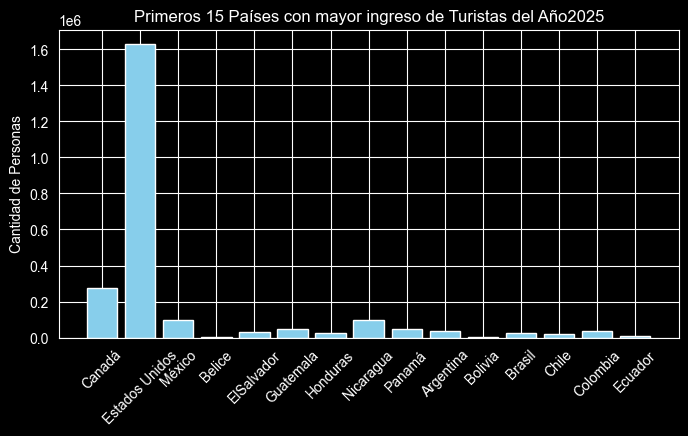

In [42]:
top_15_paises = df_paises[
    (df_paises['Zona_Pais'] != 'Total') &
    ((df_paises['Zona_Pais'] != 'América del Norte') &
     (df_paises['Zona_Pais'] != 'América Central') &
     (df_paises['Zona_Pais'] != 'América del Sur') &
     (df_paises['Zona_Pais'] != 'Caribe') &
     (df_paises['Zona_Pais'] != 'Europa') &
     (df_paises['Zona_Pais'] != 'Otras Zonas')
     )
].head(15)

for col in num_cols[1:]:
    plt.figure(figsize = (8,4))
    plt.bar(top_15_paises['Zona_Pais'], top_15_paises[col], color='skyblue')
    plt.title(f"Primeros 15 Países con mayor ingreso de Turistas del {col}")
    plt.ylabel('Cantidad de Personas')
    plt.xticks(rotation=45)
    plt.show()


# Otros gráficos

#### Preparación de los datos para los siguientes gráficos

In [45]:
annios = [col for col in df.columns if 'Año' in col]

df_total = df[df['Zona_Pais'] == 'Total']
df_paises = df[df['Zona_Pais'] != 'Total'].copy()

df_paises[annios] = df_paises[annios].fillna(0)

### Tendencia de llegadas a Costa Rica

#### Línea de tiempo

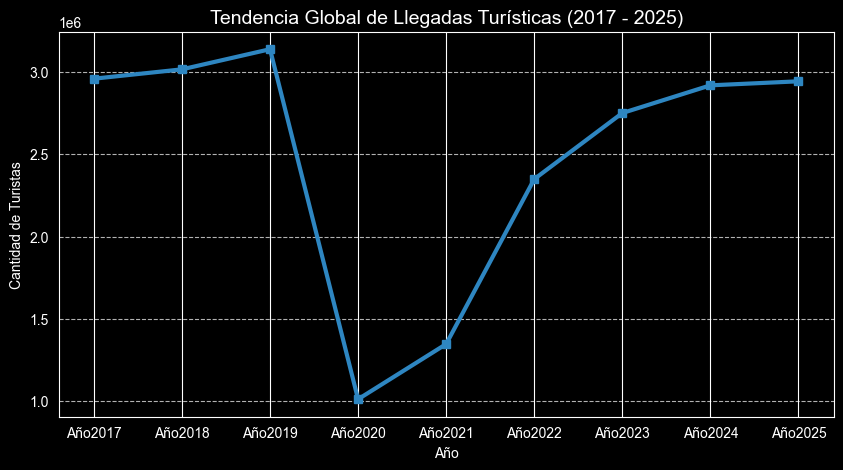

In [53]:
plt.figure(figsize=(10, 5))
plt.plot(annios, df_total[annios].values.flatten(), marker='s', color='#2E86C1', linewidth=3)

plt.title('Tendencia Global de Llegadas Turísticas (2017 - 2025)', fontsize=14)
plt.xlabel('Año')
plt.ylabel('Cantidad de Turistas')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Mapa de Calor usando los 100 registros del dataset

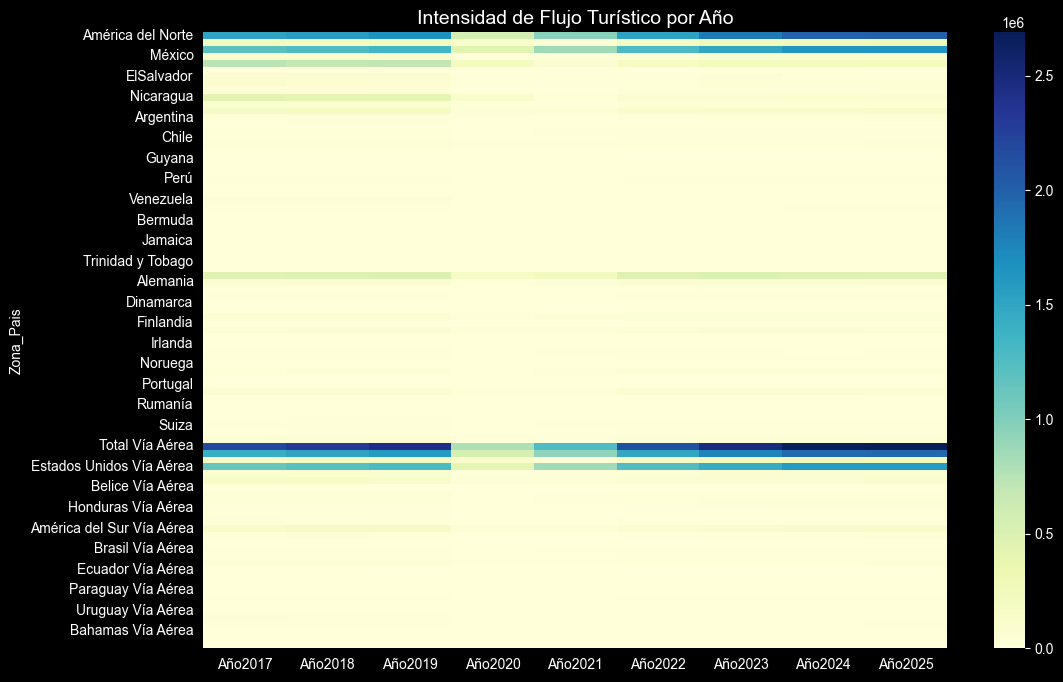

In [51]:
df_heatmap = df_paises.set_index('Zona_Pais')[annios].head(90)

plt.figure(figsize=(12, 8))
sns.heatmap(df_heatmap, cmap='YlGnBu', annot=False)

plt.title('Intensidad de Flujo Turístico por Año', fontsize=14)
plt.show()

### Mapa de Calor usando los primeros 15 registros

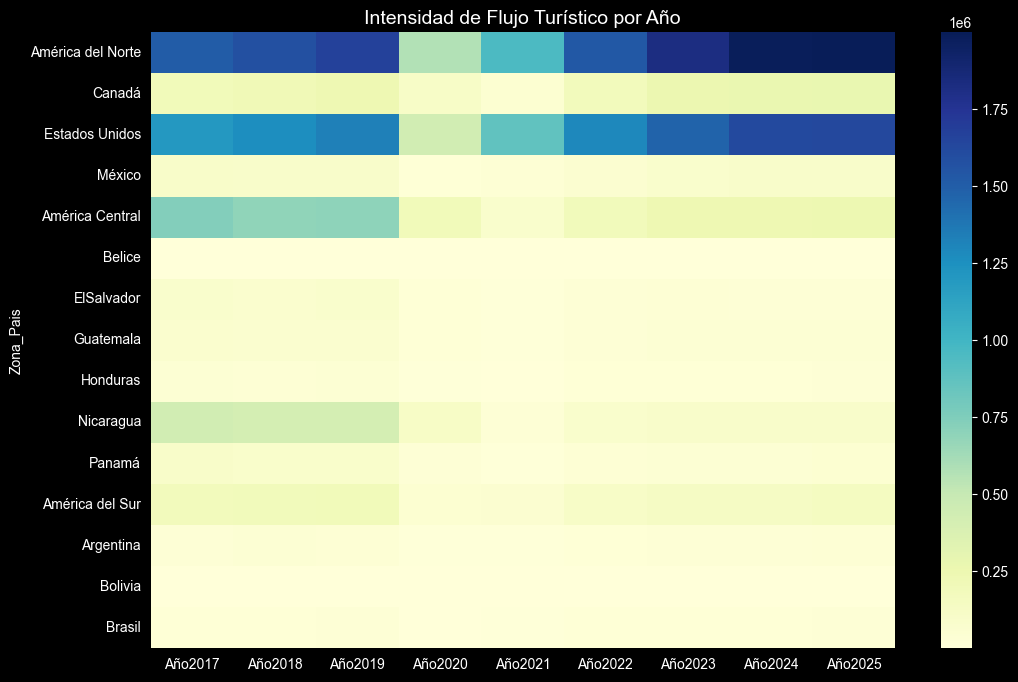

In [50]:
# Seleccionamos una muestra de 15 países para que el mapa sea legible
df_heatmap = df_paises.set_index('Zona_Pais')[annios].head(15)

plt.figure(figsize=(12, 8))
sns.heatmap(df_heatmap, cmap='YlGnBu', annot=False)

plt.title('Intensidad de Flujo Turístico por Año', fontsize=14)
plt.show()

# EDA sobre el Clima

### Carga del Dataset del Clima

In [ ]:
# Ruta PC Josué
df_clima = pd.read_csv(r'C:\Users\XPC\Documents\CUC\Cuatri 5\BD - 143 - Programación ll\Trabajos\Proyecto 3\data\raw\clima_costa_rica_nuevo.csv')

# Ruta de Mauricio
#df_clima = pd.read_csv(r'')

### Preparación de los datos

In [56]:
df_clima['time'] = pd.to_datetime(df_clima['time'])

df_clima['mes'] = df_clima['time'].dt.month
df_clima['año'] = df_clima['time'].dt.year

meses_nombres = {1:'Ene', 2:'Feb', 3:'Mar', 4:'Abr', 5:'May', 6:'Jun',
                 7:'Jul', 8:'Ago', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dic'}
df_clima['mes_nombre'] = df_clima['mes'].map(meses_nombres)

### Comportamiento de las Temperaturas - Máximos y Mínimos

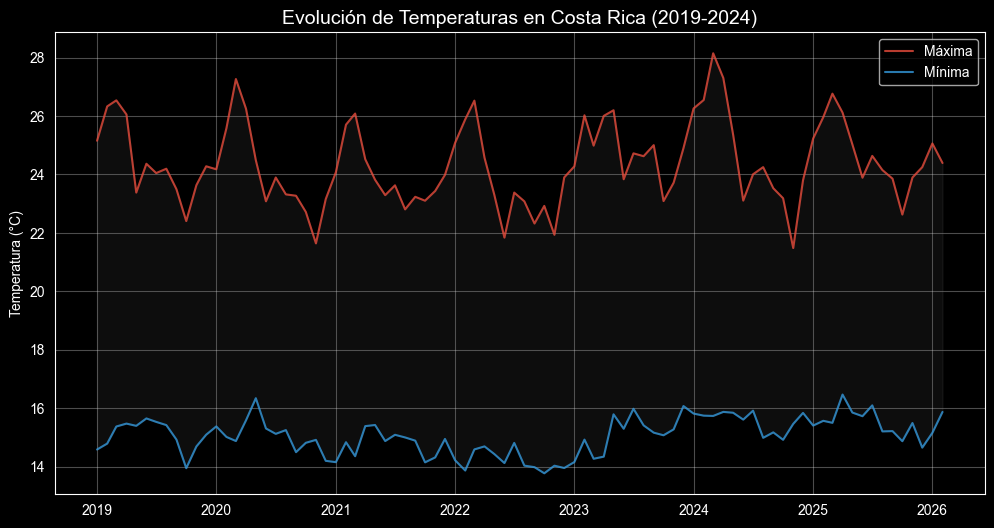

In [58]:
plt.figure(figsize=(12, 6))
plt.plot(df_clima['time'], df_clima['temperature_2m_max'], label='Máxima', color='#E74C3C', alpha=0.8)
plt.plot(df_clima['time'], df_clima['temperature_2m_min'], label='Mínima', color='#3498DB', alpha=0.8)

plt.fill_between(df_clima['time'], df_clima['temperature_2m_min'], df_clima['temperature_2m_max'], color='gray', alpha=0.1)

plt.title('Evolución de Temperaturas en Costa Rica (2019-2024)', fontsize=14)
plt.ylabel('Temperatura (°C)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Boxplot de lluvias por mes

C:\Users\XPC\AppData\Local\Temp\ipykernel_15136\2077938203.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clima, x='mes_nombre', y='precipitation_sum', palette='Blues',


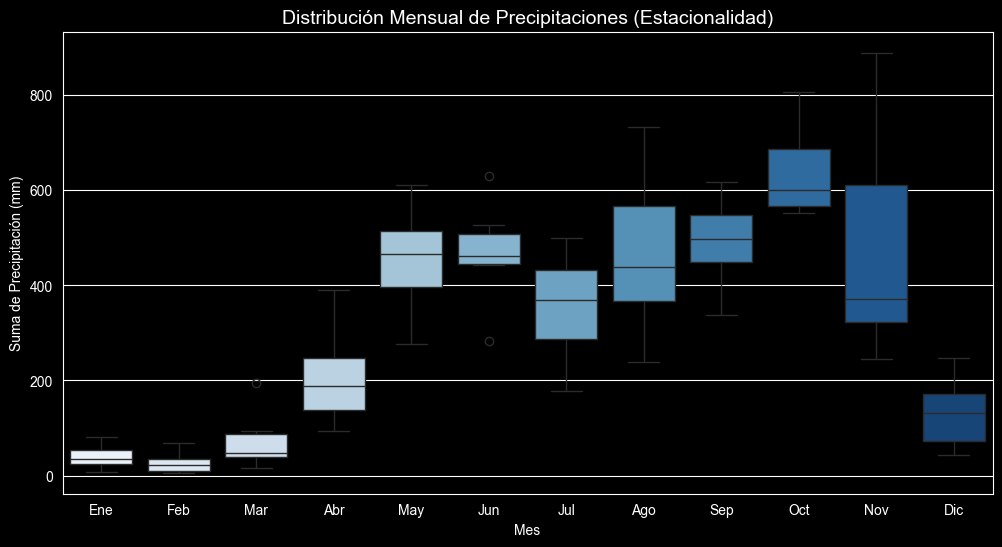

In [59]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_clima, x='mes_nombre', y='precipitation_sum', palette='Blues',
            order=['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic'])

plt.title('Distribución Mensual de Precipitaciones (Estacionalidad)', fontsize=14)
plt.xlabel('Mes')
plt.ylabel('Suma de Precipitación (mm)')
plt.show()